# 영어 학습자 에세이 어휘 수준 예측 (ELL Vocabulary Score Prediction)

영어 학습자(English Language Learner)가 작성한 에세이에서 **언어학적 지표를 추출하여 어휘 수준 점수(vocabulary)를 예측하는 회귀 모델**을 구축한 프로젝트입니다.

> 삼성중공업 스마트조선소 AI 전문가 양성과정 (KDT) — 미니프로젝트 실습평가
> 기간: 2026.08.12 ~ 2026.08.20 | 개인 프로젝트

---

## 1. 프로젝트 배경

자동 에세이 채점(Automated Essay Scoring)에서 딥러닝 기반 접근은 높은 성능을 내지만, 
**어떤 언어적 특성 때문에 그 점수가 나왔는지 설명하지 못한다**는 한계가 있습니다. 
교육 현장에서는 점수 자체보다 "왜 이 점수인가"가 더 중요합니다.

이 프로젝트는 반대 방향을 택했습니다. 블랙박스 모델 대신 **해석 가능한 언어학적 지표를 직접 설계하고**, 
그 지표들이 실제 채점자의 어휘 평가를 얼마나 설명하는지 회귀 분석으로 검증합니다. 

영어영문학 전공 배경에서 나온 어휘론·코퍼스 언어학 지식을 피처 설계에 직접 반영한 것이 이 프로젝트의 핵심입니다.

## 2. 문제 정의

| 항목 | 내용 |
|---|---|
| 문제 유형 | 지도학습 · **회귀(Regression)** |
| Target | `vocabulary` (어휘 수준 점수, 1.0 ~ 5.0, 0.5 단위) |
| Input | 에세이 원문에서 파생한 언어학적 지표 + 메타데이터 |
| 평가 지표 | MAE, MSE, RMSE, R² |

### 왜 6개 항목 중 vocabulary인가

ELLIPSE는 cohesion, syntax, vocabulary, phraseology, grammar, conventions 6개 항목 점수를 제공합니다. 그중 vocabulary를 택한 이유는 다음과 같습니다.

- **어휘 수준은 표면 지표로 측정 가능성이 높다.** 어휘 다양성(TTR, MTLD), 저빈도어 비율, 평균 어휘 길이 등 텍스트에서 직접 계산되는 지표가 어휘 능력과 직결됩니다.
- **syntax는 구문 파서 의존도가 높다.** 종속절 비율, 구문 트리 깊이 등을 계산하려면 파싱 단계가 필요해 5일 일정에 부담이 큽니다.
- 파이프라인이 완성되면 **타겟 변수만 교체하여 다른 항목으로 확장 가능**하도록 설계했습니다.

## 3. 데이터셋

**ELLIPSE Corpus** (English Language Learner Insight, Proficiency and Skills Evaluation)

- 출처: https://github.com/scrosseye/ELLIPSE-Corpus
- 규모: 약 3,900편 (미국 8~12학년 영어 학습자 작성)
- 수집 맥락: 미국 주(state) 단위 표준화 시험에서 실제 작성된 에세이
- 프롬프트: 배경지식을 요구하지 않는 독립형 주제 29종
- 채점: 훈련된 채점자 2인이 전체 숙련도 점수 및 6개 세부 항목 점수 부여

### 주요 컬럼

| 컬럼 | 설명 |
|---|---|
| `full_text` | 에세이 원문 |
| `overall` | 전체 영어 숙련도 점수 |
| `cohesion` / `syntax` / `vocabulary` / `phraseology` / `grammar` / `conventions` | 세부 항목 점수 |
| `prompt` | 작성 주제 |
| `grade` | 학년 (8~12) |
| 인구통계 정보 | 경제적 배경, 성별, 인종 |

## 4. 파이프라인

```
데이터 수집 → 파생 피처 생성 → 전처리 → EDA → 회귀 모델 구축 → 성능 개선 → Streamlit 대시보드
```

### 4.1 파생 피처 설계

에세이 원문(비정형)을 언어학적 근거를 가진 정형 피처로 변환합니다.

| 범주 | 지표 예시 | 언어학적 근거 |
|---|---|---|
| 어휘 다양성 | TTR, Root TTR, MTLD | 사용 어휘 폭을 직접 반영 |
| 어휘 정교성 | 저빈도어 비율, 평균 어휘 길이, 음절 수 | 고급 어휘 사용 여부 |
| 가독성 | Flesch-Kincaid, Gunning Fog 등 | 텍스트 복잡도 종합 지표 |
| 길이·구조 | 총 단어 수, 문장 수, 평균 문장 길이, 문단 수 | 생산성 및 전개 능력 |
| 표기 | 대소문자·구두점 사용 패턴 | 표기 규범 준수도 |

> **주의:** 총 단어 수는 점수와 강한 상관을 보이지만, 이 변수 하나에 모델이 과도하게 의존하면 "길게 쓰면 점수가 높다"는 모델이 됩니다. 이 문제를 EDA와 정규화 단계에서 다룹니다.

### 4.2 전처리

| 처리 | 내용 |
|---|---|
| 결측치 | 지표 계산 불가 케이스(문장 0개 → 평균 문장 길이 NaN), 메타데이터 결측 |
| 이상치 | 극단적으로 짧은 에세이, 채점자 간 불일치가 큰 건 |
| 중복 | 동일 텍스트 중복 제출 |
| 타입 변환 | 학년(순서형), 점수(연속형) |
| 범주형 인코딩 | `prompt`, `grade` → One-hot vs Target Encoding 비교 |
| Feature Selection | 파생 지표 다수 → 상관계수 및 VIF 기반 다중공선성 제거 |
| Scaling | StandardScaler 적용 |

**Scaling의 중요성 검증:** 파생 지표는 스케일 차이가 큽니다(총 단어 수 약 300 vs TTR 약 0.5). 스케일링을 적용하지 않으면 Ridge/Lasso의 규제가 스케일이 큰 변수에만 편향되어 작동합니다. 이를 적용 전/후로 비교하여 실증합니다.

### 4.3 모델

| 모델 | 목적 |
|---|---|
| Linear Regression | 베이스라인, 계수 해석 |
| Ridge / Lasso | 다중공선성 및 변수 선택 효과 확인 |
| Random Forest Regressor | 비선형 관계 포착, Feature Importance 도출 |

### 4.4 성능 개선 방향

- 피처 추가/제거 및 상호작용 항 생성
- 이상치 처리 기준 변경에 따른 성능 비교
- 인코딩·스케일링 방식 변경
- 하이퍼파라미터 튜닝 (GridSearchCV)

## 5. 윤리적 고려사항

ELLIPSE는 작성자의 **인종, 성별, 경제적 배경** 정보를 포함합니다.

**이 변수들은 예측 피처에서 의도적으로 제외합니다.**

이들 변수를 투입하면 성능 지표는 일부 개선될 수 있습니다. 그러나 학생의 인종이나 경제적 배경을 근거로 영어 점수를 예측하는 모델은 언어 능력을 측정하는 것이 아니라 **사회적 격차를 학습하여 재생산하는 모델**입니다. 실제 교육 현장에 배포될 경우 특정 집단에 대한 체계적 편향으로 이어집니다.

다만 해당 변수들은 **EDA 단계에서는 분석 대상으로 다룹니다.** 점수 분포가 집단별로 어떻게 다른지 확인하는 것은 데이터가 내포한 편향을 드러내는 작업이며, 모델에서 이를 배제한 판단의 근거가 됩니다.

## 6. 대시보드

Streamlit으로 구현하며 다음 화면으로 구성합니다.

1. **프로젝트 소개** — 배경 및 문제 정의
2. **데이터 정의** — 출처, 변수 설명, 기초 통계
3. **데이터 분석** — EDA 시각화, 지표-점수 상관관계
4. **모델 성능** — 모델별 MAE / RMSE / R² 비교, Feature Importance
5. **예측 시스템** — 영문 에세이를 직접 입력하면 지표를 추출하여 어휘 점수를 예측

## 7. 프로젝트 구조

```
project/
├── data/
│   ├── raw/                  # ELLIPSE 원본
│   └── processed/            # 전처리 완료 데이터
├── notebooks/
│   ├── 01_eda.ipynb
│   ├── 02_feature_engineering.ipynb
│   └── 03_modeling.ipynb
├── src/
│   ├── features.py           # 언어학적 지표 추출
│   ├── preprocess.py         # 전처리 파이프라인
│   └── train.py              # 모델 학습 및 평가
├── models/                   # 학습된 모델 저장
├── app.py                    # Streamlit 대시보드
├── requirements.txt
└── README.md
```

## 8. 실행 방법

```bash
# 가상환경 생성 및 활성화
python -m venv venv
source venv/bin/activate        # Windows: venv\Scripts\activate

# 의존성 설치
pip install -r requirements.txt

# 모델 학습
python src/train.py

# 대시보드 실행
streamlit run app.py
```

**주요 라이브러리:** pandas, numpy, scikit-learn, matplotlib, seaborn, nltk, textstat, streamlit

> 언어 지표 추출은 NLTK와 textstat 조합으로 구성했습니다. spaCy는 설치 및 언어모델 다운로드 과정에서 환경 의존성이 크고, 본 프로젝트의 어휘 관련 지표는 파서 없이도 산출 가능하기 때문입니다.

## 9. 진행 일정

| 일자 | 작업 |
|---|---|
| Day 1 | 데이터 수집, 구조 파악, 가설 설정 |
| Day 2 | 파생 피처 생성, 전처리 |
| Day 3 | EDA 및 시각화 |
| Day 4 | 회귀 모델 구축 및 평가, 성능 개선 |
| Day 5 | Streamlit 대시보드 작성, 결과 정리 |

## 10. 결과

> 진행 중 — 완료 후 업데이트 예정

| 모델 | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | - | - | - |
| Ridge | - | - | - |
| Lasso | - | - | - |
| Random Forest | - | - | - |

## 11. 참고문헌

Crossley, S. A., Tian, Y., Baffour, P., Franklin, A., Kim, Y., Morris, W., Benner, B., Picou, A., & Boser, U. (2023). Measuring second language proficiency using the English Language Learner Insight, Proficiency and Skills Evaluation (ELLIPSE) Corpus. *International Journal of Learner Corpus Research, 9*(2), 248-269.

---

**Author** 김정훈


In [12]:
# 0. 데이터 준비, EDA(Exploratory Data Analysis)
import pandas as pd


raw_data = pd.read_csv('data/ELLIPSE_Final_github_train.csv')
raw_data.head(10)
raw_data.tail(10)

,text_id_kaggle,full_text,gender,grade,race_ethnicity,num_words,num_words2,num_words3,num_sent,num_para,...,SES,prompt,Overall,Cohesion,Syntax,Vocabulary,Phraseology,Grammar,Conventions,set
3901,441097905601,"Dear Principal,\r\n\r\nI would like to tell yo...",Female,8,Asian/Pacific Islander,216,219,219,11,4,...,Not economically disadvantaged,Community service,3.5,3.5,3.0,3.5,3.0,4.0,4.0,train
3902,503960784148,In every school privated or public is they goo...,Female,11,Hispanic/Latino,698,748,728,7,6,...,Economically disadvantaged,Lunch menus,2.0,2.5,2.5,2.0,2.5,2.0,2.0,train
3903,523130079501,"""Their are advantages of cell phone usage in c...",Female,12,White,620,736,719,41,7,...,Economically disadvantaged,Cell phones in classrooms,3.5,3.5,3.5,4.0,3.0,3.0,3.5,train
3904,532528134425,A example is the best way to show others peopl...,Male,11,Hispanic/Latino,565,596,596,16,14,...,Not economically disadvantaged,Influencing behavior,3.0,3.5,2.0,3.0,3.0,2.0,3.0,train
3905,570595740274,Do students need summer break or they can hand...,Male,10,Hispanic/Latino,763,811,804,22,10,...,Not economically disadvantaged,Year-round school,3.0,3.0,2.5,3.5,3.5,2.5,3.0,train
3906,782678016796,Students believe in praising them builds their...,Male,11,Black/African American,221,243,238,12,6,...,Not economically disadvantaged,Praising student work,3.0,3.5,3.0,3.0,2.5,3.0,3.5,train
3907,833489139971,Former British Minister Winston Churchill once...,Male,11,Hispanic/Latino,772,197,197,11,3,...,Economically disadvantaged,Success and failure,3.5,3.5,3.5,3.0,3.5,4.0,3.5,train
3908,856351253492,"Author Ralph Waldo Emerson wrote, ""Unless you ...",Female,10,Hispanic/Latino,738,710,700,27,9,...,Economically disadvantaged,Trying something beyond what you have mastered,2.5,2.0,3.0,2.5,2.0,2.5,3.0,train
3909,533579606800000000,Students should commit to a career in high sch...,Male,11,Hispanic/Latino,357,363,359,18,5,...,Economically disadvantaged,Career commitment,3.0,3.0,3.0,3.0,3.0,2.5,3.0,train
3910,1780256200000000000000000000000000000000000000...,"March 12, 20019\r\n\r\nThe technology allows p...",Female,11,Hispanic/Latino,204,227,227,13,7,...,Not economically disadvantaged,Impact of technology,2.5,3.0,2.0,3.5,2.5,2.5,2.5,train


In [15]:
raw_data.columns

Index(['text_id_kaggle', 'full_text', 'gender', 'grade', 'race_ethnicity',
       'num_words', 'num_words2', 'num_words3', 'num_sent', 'num_para',
       'num_word_div_para', 'MTLD', 'TTR', 'Type', 'Token', 'task', 'SES',
       'prompt', 'Overall', 'Cohesion', 'Syntax', 'Vocabulary', 'Phraseology',
       'Grammar', 'Conventions', 'set'],
      dtype='str')

In [16]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3911 entries, 0 to 3910
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text_id_kaggle     3911 non-null   str    
 1   full_text          3911 non-null   str    
 2   gender             3911 non-null   str    
 3   grade              3911 non-null   int64  
 4   race_ethnicity     3911 non-null   str    
 5   num_words          3911 non-null   int64  
 6   num_words2         3911 non-null   int64  
 7   num_words3         3911 non-null   int64  
 8   num_sent           3911 non-null   int64  
 9   num_para           3911 non-null   int64  
 10  num_word_div_para  3911 non-null   float64
 11  MTLD               3911 non-null   float64
 12  TTR                3911 non-null   float64
 13  Type               3911 non-null   int64  
 14  Token              3911 non-null   int64  
 15  task               3911 non-null   str    
 16  SES                3911 non-null   

In [40]:
print('===== shape =====')
print(raw_data.shape)
print("\n==== columns & dtypes ====")
print(raw_data.dtypes)
print("\n==== 결측치 ====")
print(raw_data.isnull().sum())
print("\n==== 앞 3행 ====")
print(raw_data.head(3))
print("\n=== 기술통계 ===")
print(raw_data.describe())

===== shape =====
(3911, 26)

==== columns & dtypes ====
text_id_kaggle           str
full_text                str
gender                   str
grade                  int64
race_ethnicity           str
num_words              int64
num_words2             int64
num_words3             int64
num_sent               int64
num_para               int64
num_word_div_para    float64
MTLD                 float64
TTR                  float64
Type                   int64
Token                  int64
task                     str
SES                      str
prompt                   str
Overall              float64
Cohesion             float64
Syntax               float64
Vocabulary           float64
Phraseology          float64
Grammar              float64
Conventions          float64
set                      str
dtype: object

==== 결측치 ====
text_id_kaggle       0
full_text            0
gender               0
grade                0
race_ethnicity       0
num_words            0
num_words2           0

In [41]:
raw_data['set']

0       train
1       train
2       train
3       train
4       train
        ...  
3906    train
3907    train
3908    train
3909    train
3910    train
Name: set, Length: 3911, dtype: str

In [21]:
raw_data['set'].value_counts()

set
train    3911
Name: count, dtype: int64

In [32]:
print(len(raw_data), raw_data['prompt'].nunique())
print(raw_data['prompt'].value_counts())

3911 44
prompt
Distance learning                                 297
Career commitment                                 227
Success and failure                               218
Being busy                                        209
Positive attitudes                                178
Impact of technology                              176
Trying something beyond what you have mastered    172
First impressions                                 169
Three-year high school program                    153
Individuality                                     147
Four-day work week                                137
Working with a group or alone                     135
Self-reliance                                     131
Lunch menus                                        93
Influences of character                            92
Extended school day                                90
Year-round school                                  67
Influencing behavior                               64
Cell phones i

In [35]:
print(raw_data['Vocabulary'].value_counts().sort_index())
print(raw_data[['num_words','MTLD','TTR','num_sent','num_para']].describe())

Vocabulary
1.0       2
1.5      14
2.0     124
2.5     528
3.0    1503
3.5    1007
4.0     577
4.5     115
5.0      41
Name: count, dtype: int64
         num_words         MTLD          TTR     num_sent     num_para
count  3911.000000  3911.000000  3911.000000  3911.000000  3911.000000
mean    436.777550    45.977157    36.936004    18.265661     5.538481
std     232.636558    10.976797     8.199147    10.260631     3.117805
min      13.000000    12.250000    14.008322     1.000000     1.000000
25%     285.000000    38.184060    31.239766    10.000000     4.000000
50%     391.000000    44.912469    36.254980    17.000000     5.000000
75%     523.000000    52.167603    42.023506    24.000000     6.000000
max    2611.000000   103.142182    92.857143    99.000000    52.000000


<Axes: xlabel='num_words'>

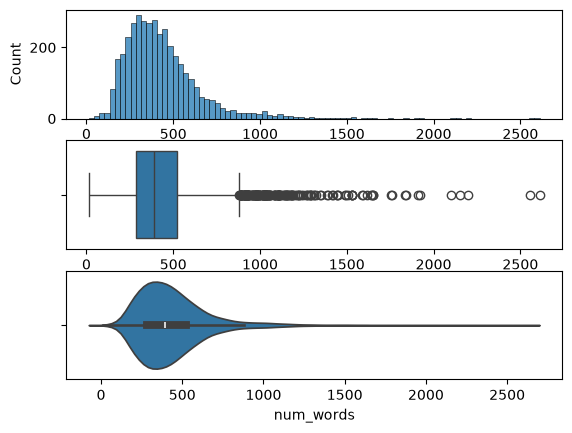

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplot(3, 1, 1)
sns.histplot(data=raw_data, x="num_words")
plt.subplot(3, 1, 2)
sns.boxplot(data=raw_data, x="num_words")
plt.subplot(3, 1, 3)
sns.violinplot(data=raw_data, x="num_words")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplot(3, 1, 1)
sns.histplot(data=raw_data, x="num_words")
plt.subplot(3, 1, 2)
sns.boxplot(data=raw_data, x="num_words")
plt.subplot(3, 1, 3)
sns.violinplot(data=raw_data, x="num_words")

# ELLIPSE 코퍼스 — 데이터 정의서

**파일**: `ELLIPSE_Final_github_train.csv`
**규모**: 3,911행 × 26컬럼
**결측치**: 없음 (전 컬럼 0개)
**출처**: [scrosseye/ELLIPSE-Corpus](https://github.com/scrosseye/ELLIPSE-Corpus)

---

## 컬럼 목록

| # | 컬럼명 | 타입 | 고유값 | 범위 / 분포 | 설명 |
|---:|---|---|---:|---|---|
| 1 | `text_id_kaggle` | object | 3,911 | 대부분 12자리 hex | 에세이 고유 식별자 (Kaggle Feedback Prize ID 체계) |
| 2 | `full_text` | object | 3,911 | — | 에세이 원문 전체 |
| 3 | `gender` | object | 2 | Male 2,190 / Female 1,721 | 학습자 성별 |
| 4 | `grade` | int64 | 5 | 8 ~ 12 (평균 10.52) | 학년. 11(1,377) · 12(1,319) · 8(975) · 10(214) · 9(26) |
| 5 | `race_ethnicity` | object | 6 | Hispanic/Latino 2,767 최다 | 인종·민족 |
| 6 | `num_words` | int64 | 850 | 13 ~ 2,611 (평균 436.78) | 단어 수 — 정의 불명, 타 지표와 상관 0.78 |
| 7 | `num_words2` | int64 | 824 | 14 ~ 1,268 (평균 436.40) | 공백 기준 토큰 수 — `Token`과 값 완전 동일 |
| 8 | `num_words3` | int64 | 816 | 14 ~ 1,260 (평균 430.49) | `num_words2`보다 평균 5.9 적음 (구두점·숫자 제외 추정) |
| 9 | `num_sent` | int64 | 66 | 1 ~ 99 (평균 18.27) | 문장 수 |
| 10 | `num_para` | int64 | 32 | 1 ~ 52 (평균 5.54) | 문단 수 |
| 11 | `num_word_div_para` | float64 | 1,895 | 3.50 ~ 1,192.00 (평균 94.46) | 평균 문단 길이 (문단별 단어 수의 산술평균) |
| 12 | `MTLD` | float64 | 3,890 | 12.25 ~ 103.14 (평균 45.98) | 어휘 다양성 지표. 글 길이에 덜 민감 |
| 13 | `TTR` | float64 | 3,479 | 14.01 ~ 92.86 (평균 36.94) | Type-Token Ratio = `Type / Token × 100` |
| 14 | `Type` | int64 | 280 | 13 ~ 387 (평균 150.77) | 고유 단어 종류 수 |
| 15 | `Token` | int64 | 824 | 14 ~ 1,268 (평균 436.40) | 총 토큰 수 |
| 16 | `task` | object | **1** | 전부 `Independent` | 과제 유형 (자료 없이 쓰는 독립 작문) |
| 17 | `SES` | object | 2 | 경제적 취약 2,709 / 비취약 1,202 | 사회경제적 지위 |
| 18 | `prompt` | object | 44 | Distance learning 297 최다 | 에세이 주제 |
| 19 | `Overall` | float64 | 9 | 1.0 ~ 5.0 (평균 3.11) | 종합 점수 |
| 20 | `Cohesion` | float64 | 9 | 1.0 ~ 5.0 (평균 3.13) | 응집성 |
| 21 | `Syntax` | float64 | 9 | 1.0 ~ 5.0 (평균 3.03) | 구문 |
| 22 | `Vocabulary` | float64 | 9 | 1.0 ~ 5.0 (평균 3.24) | 어휘 |
| 23 | `Phraseology` | float64 | 9 | 1.0 ~ 5.0 (평균 3.12) | 연어·표현 |
| 24 | `Grammar` | float64 | 9 | 1.0 ~ 5.0 (평균 3.03) | 문법 |
| 25 | `Conventions` | float64 | 9 | 1.0 ~ 5.0 (평균 3.08) | 표기 규범 (철자·구두점 등) |
| 26 | `set` | object | **1** | 전부 `train` | 데이터 분할 표시 |

---

## 컬럼 간 확인된 관계

| 관계 | 검증 결과 |
|---|---|
| `num_words2` = `Token` | 3,911행 전부 일치 |
| `TTR` = `Type` / `Token` × 100 | 전부 일치 (오차 1e-4 이내) |
| `num_word_div_para` = 문단별 단어 수의 평균 | 전부 일치 (오차 1e-3 이내) |
| `num_words3` ≈ `num_words2` | 상관 0.9993, 평균 차이 5.9 |
| `Overall` = 나머지 6개 점수의 평균 | **불일치** — 별도로 매겨진 독립 점수 |

## 점수 컬럼 공통 사항

7개 점수(`Overall`, `Cohesion`, `Syntax`, `Vocabulary`, `Phraseology`, `Grammar`, `Conventions`) 모두 동일한 척도를 사용한다.

- 범위: 1.0 ~ 5.0
- 간격: 0.5 단위 → 고유값 9개 (1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0)
- 평균 3.03 ~ 3.24, 표준편차 0.58 ~ 0.70 → 중앙에 집중된 분포

`Overall`과 나머지 6개의 상관계수는 0.774 ~ 0.812이다.

## 데이터 전처리 1 (가비지 컬럼 삭제)
### 삭제할 컬럼:
#### 가비지 컬럼 (중복 또는 단순 인덱스)
- text_id_kaggle : 단순 데이터 구분용 식별자 (캐글에서 붙임.)
- set : 데이터가 학습용인지, 검증용인지 분류 (애초에 학습용 데이터만 모은 csv이므로 컬럼 삭제)
- num_words2 : Token과 중복되는 컬럼(완벽히 일치)
-----------
#### 인구통계 컬럼 (윤리적 문제)
- gender : 성별
- race_ethnicity : 인종
- SES : 사회경제적 지위
-----------
#### 데이터 누수 컬럼 (모델이 알면 안되는 값)
- Overall

In [ ]:
X = raw_data.drop(['text_id_kaggle', 'set', 'num_words', 'gender', 'race_ethnicity', 'SES', ], axis=1)

1